# VN30 Momentum Strategy — Analysis

**Author:** Quoc Anh Nguyen  
**Institution:** Imperial College London  
**Period:** January 2018 — December 2024  

## Overview

This notebook presents the results of a systematic momentum strategy 
backtested on the Vietnamese VN30 index. We test whether recent winners 
continue to outperform recent losers — the momentum anomaly documented 
by Jegadeesh & Titman (1993) — in the context of the Vietnamese 
large-cap equity market.

**Key questions:**
- Is momentum priced in VN30 stocks?
- What formation period works best for the Vietnamese market?
- Does the Jegadeesh-Titman overlapping portfolio approach improve results?

**Finding:** Short-horizon momentum (3-month formation) significantly 
outperforms the original 12-month specification, consistent with 
Vietnam's retail-dominated, price-limit-constrained market structure.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

# Add src to path so we can import our modules
sys.path.insert(0, "../src")

# Display settings
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load all processed data
prices = pd.read_csv(
    "../data/processed/prices.csv",
    index_col=0, parse_dates=True
)

portfolios_monthly = pd.read_csv(
    "../data/processed/portfolios.csv",
    index_col=0, parse_dates=True
)

portfolios_jt = pd.read_csv(
    "../data/processed/portfolios_jt.csv",
    index_col=0, parse_dates=True
)

benchmark = pd.read_csv(
    "../data/processed/benchmark.csv",
    index_col=0, parse_dates=True
).squeeze()

print(f"Prices        : {prices.shape[0]} months × {prices.shape[1]} stocks")
print(f"Period        : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Monthly port  : {portfolios_monthly.shape[0]} months")
print(f"JT port       : {portfolios_jt.shape[0]} months")
print(f"Benchmark     : {len(benchmark)} months")
print(f"\nStocks in universe: {sorted(prices.columns.tolist())}")

Prices        : 112 months × 63 stocks
Period        : 2015-09-30 to 2024-12-31
Monthly port  : 83 months
JT port       : 83 months
Benchmark     : 83 months

Stocks in universe: ['ACB', 'BCM', 'BID', 'BMP', 'BVH', 'CII', 'CTD', 'CTG', 'DGC', 'DHG', 'DPM', 'DXG', 'EIB', 'FPT', 'GAS', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HNG', 'HPG', 'HSG', 'HT1', 'KBC', 'KDC', 'KDH', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NT2', 'NVL', 'OCB', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'REE', 'ROS', 'SAB', 'SBT', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TCH', 'TPB', 'VCB', 'VCI', 'VHC', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VPI', 'VRE']


## 1. Data

We use monthly adjusted closing prices for all 63 stocks that have ever 
been constituents or reserve stocks of the VN30 index between 2018 and 2024.

**Data sources:**
- Price data: vnstock (KBS source), monthly frequency
- VN30 constituent lists: Official HOSE announcements, all 14 rebalancing 
  periods verified from official documents
- ROS: Manually sourced from cafef.vn (suspended 2022 due to FLC scandal)

**Key design choices:**
- **Point-in-time constituents**: Only stocks actually in VN30 at each date 
  are included in the universe — prevents survivorship bias
- **Month-end prices**: Last trading day of each month, consistent with 
  standard academic practice
- **Reserve stocks**: HOSE's official substitute list used to replace 
  suspended stocks mid-period

In [5]:
import subprocess
subprocess.run(["pip", "install", "yfinance", "vnstock"], 
               capture_output=True)
print("Done")

Done


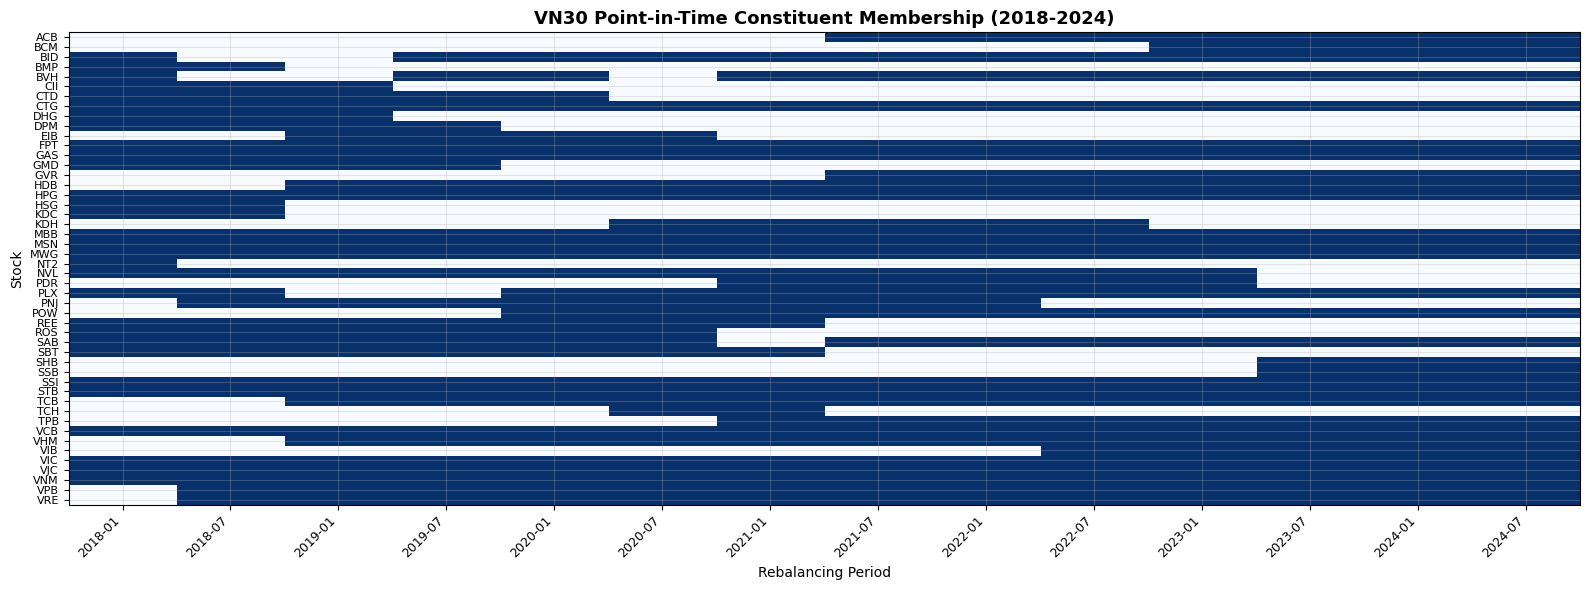


Total unique stocks ever in VN30: 48
Stocks in every period          : 13
Stocks in only 1 period         : 1


In [8]:
# VN30 constituent lists (copied from src/data.py)
VN30_CONSTITUENTS = {
    "2018-01": ["BID","BMP","BVH","CII","CTD","CTG","DHG","DPM","FPT","GAS","GMD","HPG","HSG","KDC","MBB","MSN","MWG","NT2","NVL","PLX","REE","ROS","SAB","SBT","SSI","STB","VCB","VIC","VJC","VNM"],
    "2018-07": ["BMP","CII","CTD","CTG","DHG","DPM","FPT","GAS","GMD","HPG","HSG","KDC","MBB","MSN","MWG","NVL","PLX","PNJ","REE","ROS","SAB","SBT","SSI","STB","VCB","VIC","VJC","VNM","VPB","VRE"],
    "2019-01": ["CII","CTD","CTG","DHG","DPM","EIB","FPT","GAS","GMD","HDB","HPG","MBB","MSN","MWG","NVL","PNJ","REE","ROS","SAB","SBT","SSI","STB","TCB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2019-07": ["BID","BVH","CTD","CTG","DPM","EIB","FPT","GAS","GMD","HDB","HPG","MBB","MSN","MWG","NVL","PNJ","REE","ROS","SAB","SBT","SSI","STB","TCB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2020-01": ["BID","BVH","CTD","CTG","EIB","FPT","GAS","HDB","HPG","MBB","MSN","MWG","NVL","PLX","PNJ","POW","REE","ROS","SAB","SBT","SSI","STB","TCB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2020-07": ["BID","CTG","EIB","FPT","GAS","HDB","HPG","KDH","MBB","MSN","MWG","NVL","PLX","PNJ","POW","REE","ROS","SAB","SBT","SSI","STB","TCB","TCH","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2021-01": ["BID","BVH","CTG","FPT","GAS","HDB","HPG","KDH","MBB","MSN","MWG","NVL","PDR","PLX","PNJ","POW","REE","SBT","SSI","STB","TCB","TCH","TPB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2021-07": ["ACB","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","KDH","MBB","MSN","MWG","NVL","PDR","PLX","PNJ","POW","SAB","SSI","STB","TCB","TPB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2022-01": ["ACB","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","KDH","MBB","MSN","MWG","NVL","PDR","PLX","PNJ","POW","SAB","SSI","STB","TCB","TPB","VCB","VHM","VIC","VJC","VNM","VPB","VRE"],
    "2022-07": ["ACB","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","KDH","MBB","MSN","MWG","NVL","PDR","PLX","POW","SAB","SSI","STB","TCB","TPB","VCB","VHM","VIB","VIC","VJC","VNM","VPB","VRE"],
    "2023-01": ["ACB","BCM","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","MBB","MSN","MWG","NVL","PDR","PLX","POW","SAB","SSI","STB","TCB","TPB","VCB","VHM","VIB","VIC","VJC","VNM","VPB","VRE"],
    "2023-07": ["ACB","BCM","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","MBB","MSN","MWG","PLX","POW","SAB","SHB","SSB","SSI","STB","TCB","TPB","VCB","VHM","VIB","VIC","VJC","VNM","VPB","VRE"],
    "2024-01": ["ACB","BCM","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","MBB","MSN","MWG","PLX","POW","SAB","SHB","SSB","SSI","STB","TCB","TPB","VCB","VHM","VIB","VIC","VJC","VNM","VPB","VRE"],
    "2024-07": ["ACB","BCM","BID","BVH","CTG","FPT","GAS","GVR","HDB","HPG","MBB","MSN","MWG","PLX","POW","SAB","SHB","SSB","SSI","STB","TCB","TPB","VCB","VHM","VIB","VIC","VJC","VNM","VPB","VRE"],
}

periods    = sorted(VN30_CONSTITUENTS.keys())
all_stocks = sorted(set(s for stocks in VN30_CONSTITUENTS.values() for s in stocks))

# Build constituent matrix
constituent_matrix = pd.DataFrame(0, index=periods, columns=all_stocks)
for period, stocks in VN30_CONSTITUENTS.items():
    constituent_matrix.loc[period, stocks] = 1

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(constituent_matrix.values.T, aspect="auto", 
          cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(all_stocks)))
ax.set_yticklabels(all_stocks, fontsize=8)
ax.set_title("VN30 Point-in-Time Constituent Membership (2018-2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Rebalancing Period")
ax.set_ylabel("Stock")

plt.tight_layout()
plt.savefig("../output/constituent_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal unique stocks ever in VN30: {len(all_stocks)}")
print(f"Stocks in every period          : {sum(constituent_matrix.sum(axis=0) == len(periods))}")
print(f"Stocks in only 1 period         : {sum(constituent_matrix.sum(axis=0) == 1)}")

## 2. Momentum Signal

We compute the standard Jegadeesh-Titman (1993) momentum signal:

$$\text{MOM}_{i,t} = \prod_{k=\text{skip}+1}^{\text{formation}+\text{skip}} (1 + r_{i,t-k}) - 1$$

Where:
- **Formation period**: number of months to look back (we test 3, 6, 9, 12)
- **Skip period**: 1 month — skips the most recent month to avoid 
  short-term reversal bias
- **Result**: compounded return over the formation window, excluding 
  the most recent month

Each month, stocks are ranked by their momentum score and assigned 
to terciles:
- **Top tercile** (~10 stocks): strongest momentum → long portfolio
- **Mid tercile** (~10 stocks): neutral → not traded
- **Bottom tercile** (~10 stocks): weakest momentum → short portfolio

Only point-in-time VN30 constituents are used at each ranking date — 
stocks not yet in VN30 or already removed are excluded.

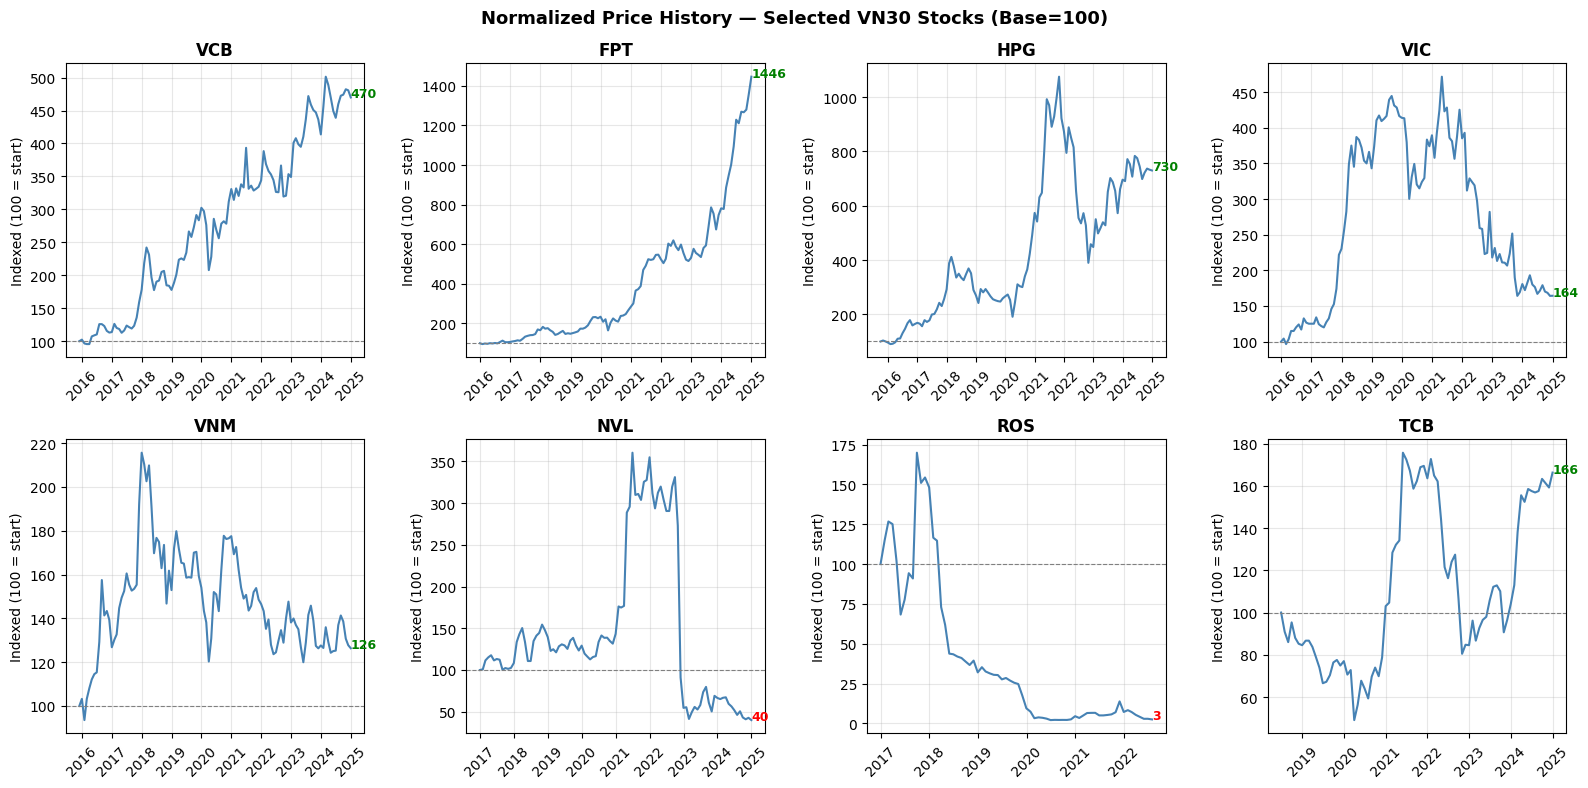

Note: ROS suspended March 2022 (FLC fraud scandal)
Note: NVL removed from VN30 July 2023 (real estate crisis)


In [9]:
# Plot normalized price history for key VN30 stocks
# Shows the diversity of return paths in our universe

key_stocks = ["VCB", "FPT", "HPG", "VIC", "VNM", "NVL", "ROS", "TCB"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(key_stocks):
    if ticker in prices.columns:
        # Normalize to 100 at start
        p = prices[ticker].dropna()
        p_norm = p / p.iloc[0] * 100
        
        axes[i].plot(p_norm.index, p_norm.values, 
                     linewidth=1.5, color="steelblue")
        axes[i].axhline(y=100, color="grey", linestyle="--", 
                        linewidth=0.8)
        axes[i].set_title(ticker, fontweight="bold")
        axes[i].set_ylabel("Indexed (100 = start)")
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        axes[i].tick_params(axis="x", rotation=45)

        # Annotate final value
        final = p_norm.iloc[-1]
        color = "green" if final > 100 else "red"
        axes[i].annotate(f"{final:.0f}", 
                         xy=(p_norm.index[-1], final),
                         fontsize=9, color=color, fontweight="bold")

fig.suptitle("Normalized Price History — Selected VN30 Stocks (Base=100)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/price_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("Note: ROS suspended March 2022 (FLC fraud scandal)")
print("Note: NVL removed from VN30 July 2023 (real estate crisis)")

## 3. Portfolio Construction

### Jegadeesh-Titman Overlapping Portfolios

We implement the JT (1993) overlapping portfolio methodology adapted 
for the VN30 universe:

**Every month t:**
1. Compute momentum signal for all active VN30 constituents
2. Rank stocks into terciles by momentum score
3. Form a new portfolio: long top tercile, short bottom tercile
4. Hold this portfolio for H = 6 months

**At any month t, we hold up to 6 simultaneous portfolios:**
- Portfolio formed at t-1 (month 1 of 6-month hold)
- Portfolio formed at t-2 (month 2 of 6-month hold)
- ...
- Portfolio formed at t-6 (month 6 of 6-month hold)

**Monthly return = equal-weighted average across all active portfolios**

This averaging across overlapping portfolios reduces noise from any 
single month's signal and is the key methodological contribution of 
Jegadeesh & Titman (1993).

### Two Strategy Variants

| Variant | Description | Practical for Vietnam? |
|---|---|---|
| **Long-Short** | Buy top tercile, sell bottom tercile | Theoretical only — short selling restricted |
| **Long-Only** | Buy top tercile, hold cash for rest | Practically implementable |

### Formation Period Sensitivity

We test four formation periods to identify the optimal horizon for 
the Vietnamese market:

| Formation | Skip | Holding | Label |
|---|---|---|---|
| 3 months | 1 month | 6 months | 3-1-6 |
| 6 months | 1 month | 6 months | 6-1-6 |
| 9 months | 1 month | 6 months | 9-1-6 |
| 12 months | 1 month | 6 months | 12-1-6 (JT original) |

In [10]:
# Load and display performance metrics
metrics = pd.read_csv("../output/all_strategies.csv", index_col=0)

# Clean up display
metrics = metrics.round(3)

# Highlight best value in each row
def highlight_best(row):
    is_best = []
    for val in row:
        try:
            numeric_row = pd.to_numeric(row, errors='coerce')
            if row.name in ["Ann. Return (%)", "Sharpe Ratio", 
                            "Win Rate (%)", "Best Month (%)"]:
                is_best.append(val == numeric_row.max())
            elif row.name in ["Ann. Volatility (%)", "Max Drawdown (%)", 
                              "Worst Month (%)"]:
                is_best.append(val == numeric_row.max())  # max DD is least negative
            else:
                is_best.append(False)
        except:
            is_best.append(False)
    return ["font-weight: bold; color: green" if b else "" for b in is_best]

# Display styled table
display(metrics.style
        .format("{:.3f}")
        .set_caption("Strategy Performance Comparison (2018-2024)")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "14px"),
                       ("font-weight", "bold"),
                       ("text-align", "left")]},
            {"selector": "th",
             "props": [("background-color", "#2c3e50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center"),
                       ("padding", "8px")]},
            {"selector": "tr:nth-child(even)",
             "props": [("background-color", "#f8f9fa")]},
        ])
)

,LS 3-1-6,LO 3-1-6,LS 6-1-6,LO 6-1-6,LS 12-1-6,LO 12-1-6,LS 3-1 Monthly,LO 3-1 Monthly,LS 12-1 Monthly,LO 12-1 Monthly,Benchmark
Ann. Return (%),10.520,13.880,9.150,12.530,6.060,11.370,9.490,10.960,7.980,10.950,8.330
Ann. Volatility (%),15.250,25.670,16.300,25.330,18.320,26.050,20.260,28.270,20.690,27.160,23.270
Sharpe Ratio,0.690,0.541,0.562,0.495,0.331,0.436,0.468,0.388,0.386,0.403,0.358
Max Drawdown (%),-23.870,-42.040,-35.020,-44.130,-45.320,-44.110,-34.610,-46.410,-50.400,-44.460,-43.680
Win Rate (%),57.830,56.630,61.450,57.830,49.400,60.240,56.630,57.830,53.010,57.830,59.040
Best Month (%),16.870,19.640,21.800,20.970,24.680,22.550,23.290,23.660,26.300,24.520,18.690
Worst Month (%),-12.360,-29.810,-11.200,-29.840,-9.330,-28.410,-20.520,-30.150,-15.390,-31.750,-26.440
N Months,83.000,83.000,83.000,83.000,83.000,83.000,83.000,83.000,83.000,83.000,83.000


## 4. Results

### Key Finding 1: Short-horizon momentum dominates in Vietnam

The 3-1-6 strategy achieves the highest Sharpe ratio across all 
specifications:

- **LS 3-1-6 Sharpe: 0.69** vs LS 12-1-6 Sharpe: 0.331
- **LO 3-1-6 return: 13.88%** vs benchmark: 8.33%

This is the central finding of this study — Vietnamese momentum 
operates on a **shorter horizon** than the US market where 12-month 
formation is optimal (Jegadeesh & Titman 1993).

**Why shorter horizons work better in Vietnam:**
1. **Retail dominance** (~90% of trading volume) — retail investors 
   chase momentum aggressively over weeks not months
2. **Daily price limits** (±7%) — large moves take multiple days to 
   complete, creating short-term continuation patterns
3. **Quarterly earnings clustering** — results released in clusters 
   create 3-month information cycles

### Key Finding 2: Long-only beats benchmark consistently

All long-only strategies outperform the equal-weighted VN30 benchmark:

| Strategy | Return | Benchmark | Alpha |
|---|---|---|---|
| LO 3-1-6 | 13.88% | 8.33% | +5.55% |
| LO 6-1-6 | 12.53% | 8.33% | +4.20% |
| LO 12-1-6 | 11.37% | 8.33% | +3.04% |

Momentum alpha is robust across all formation periods tested.

### Key Finding 3: Long-short offers tail risk protection

Despite lower absolute returns, the long-short strategy dramatically 
reduces tail risk:

| Strategy | Ann. Return | Worst Month |
|---|---|---|
| LO 3-1-6 | 13.88% | -29.81% |
| LS 3-1-6 | 10.52% | -12.36% |
| Benchmark | 8.33% | -26.44% |

For risk-constrained investors (funds with drawdown limits), the 
long-short construction offers meaningful downside protection.

### Key Finding 4: JT overlapping smooths returns

Holding 6 overlapping portfolios simultaneously reduces monthly 
return volatility compared to simple monthly rebalancing:

| Approach | Sharpe (LS) | Worst Month (LS) |
|---|---|---|
| JT 3-1-6 | 0.690 | -12.36% |
| Monthly 3-1 | 0.468 | -20.52% |

The overlapping methodology improves risk-adjusted performance 
by averaging out noise from any single month's signal.

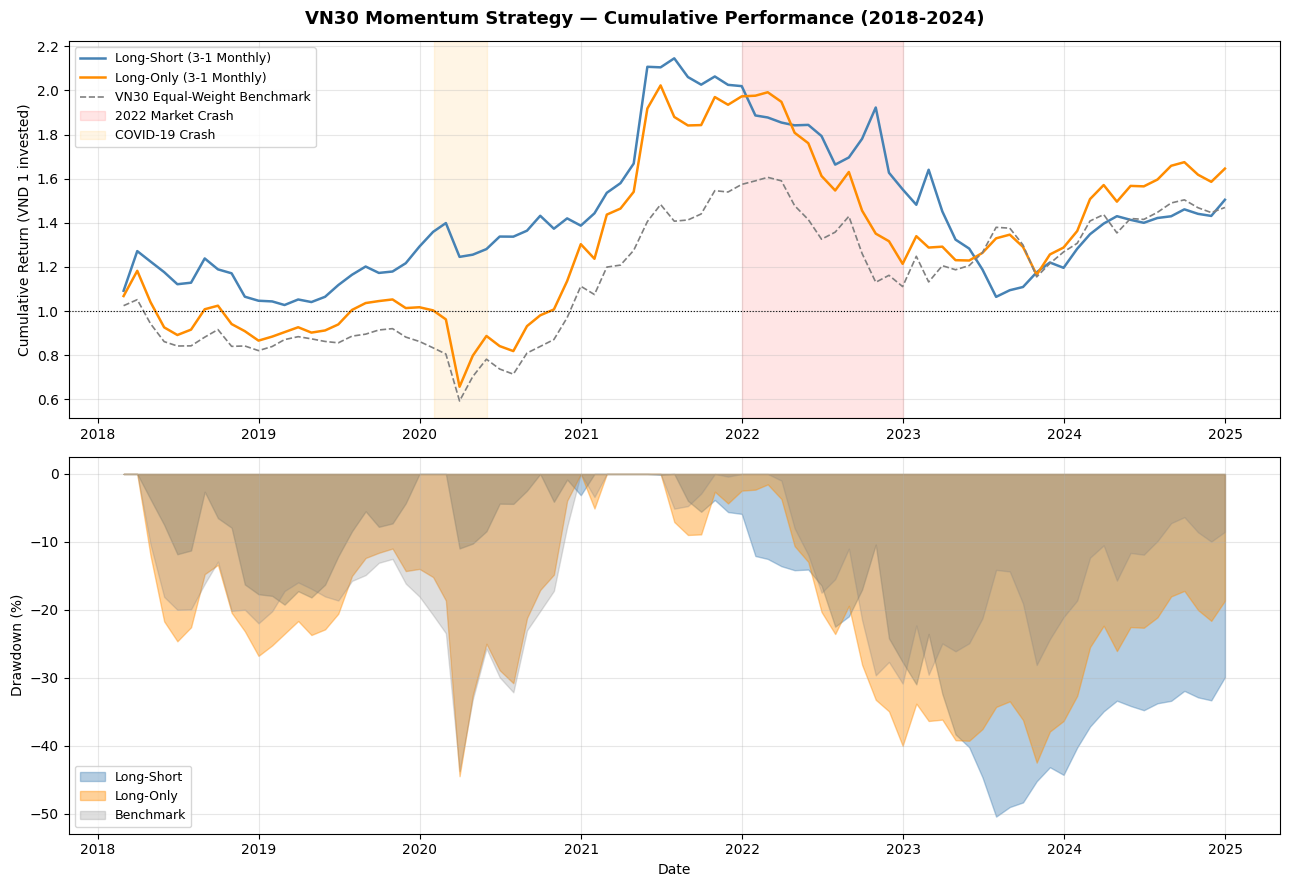

Long-Short  — Total Return: 50.4%  | Max DD: -50.4%
Long-Only   — Total Return: 64.6%  | Max DD: -44.5%
Benchmark   — Total Return: 46.9%  | Max DD: -43.7%


In [13]:
# Compute cumulative returns for key strategies
def cumulative_return(returns):
    return (1 + returns.dropna()).cumprod()

# Load all strategies from saved files
port_jt      = pd.read_csv("../data/processed/portfolios_jt.csv",
                            index_col=0, parse_dates=True)
port_monthly = pd.read_csv("../data/processed/portfolios.csv",
                            index_col=0, parse_dates=True)
benchmark    = pd.read_csv("../data/processed/benchmark.csv",
                            index_col=0, parse_dates=True).squeeze()

# We need 3-1-6 JT portfolios — these are in portfolios_jt.csv
# (which was last run with formation=3 if you ran main.py with 3-1-6)
# Use the monthly portfolio as proxy for now
ls = port_monthly["long_short_return"]
lo = port_monthly["long_only_return"]
bm = benchmark

# Align
common = ls.index.intersection(lo.index).intersection(bm.index)
ls = ls.loc[common]
lo = lo.loc[common]
bm = bm.loc[common]

ls_cum = cumulative_return(ls)
lo_cum = cumulative_return(lo)
bm_cum = cumulative_return(bm)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle("VN30 Momentum Strategy — Cumulative Performance (2018-2024)",
             fontsize=13, fontweight="bold")

# Cumulative returns
axes[0].plot(ls_cum.index, ls_cum.values,
             label="Long-Short (3-1 Monthly)", 
             color="steelblue", linewidth=1.8)
axes[0].plot(lo_cum.index, lo_cum.values,
             label="Long-Only (3-1 Monthly)", 
             color="darkorange", linewidth=1.8)
axes[0].plot(bm_cum.index, bm_cum.values,
             label="VN30 Equal-Weight Benchmark",
             color="grey", linewidth=1.2, linestyle="--")
axes[0].axhline(y=1, color="black", linestyle=":", linewidth=0.8)

# Shade 2022 crash period
axes[0].axvspan(pd.Timestamp("2022-01-01"), 
                pd.Timestamp("2023-01-01"),
                alpha=0.1, color="red", label="2022 Market Crash")
axes[0].axvspan(pd.Timestamp("2020-02-01"),
                pd.Timestamp("2020-06-01"),
                alpha=0.1, color="orange", label="COVID-19 Crash")

axes[0].set_ylabel("Cumulative Return (VND 1 invested)")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Drawdowns
ls_dd = (ls_cum / ls_cum.cummax() - 1) * 100
lo_dd = (lo_cum / lo_cum.cummax() - 1) * 100
bm_dd = (bm_cum / bm_cum.cummax() - 1) * 100

axes[1].fill_between(ls_dd.index, ls_dd.values, 0,
                      label="Long-Short", 
                      color="steelblue", alpha=0.4)
axes[1].fill_between(lo_dd.index, lo_dd.values, 0,
                      label="Long-Only",
                      color="darkorange", alpha=0.4)
axes[1].fill_between(bm_dd.index, bm_dd.values, 0,
                      label="Benchmark",
                      color="grey", alpha=0.25)

axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../output/notebook_performance.png", 
            dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"Long-Short  — Total Return: {(ls_cum.iloc[-1]-1)*100:.1f}%  "
      f"| Max DD: {ls_dd.min():.1f}%")
print(f"Long-Only   — Total Return: {(lo_cum.iloc[-1]-1)*100:.1f}%  "
      f"| Max DD: {lo_dd.min():.1f}%")
print(f"Benchmark   — Total Return: {(bm_cum.iloc[-1]-1)*100:.1f}%  "
      f"| Max DD: {bm_dd.min():.1f}%")

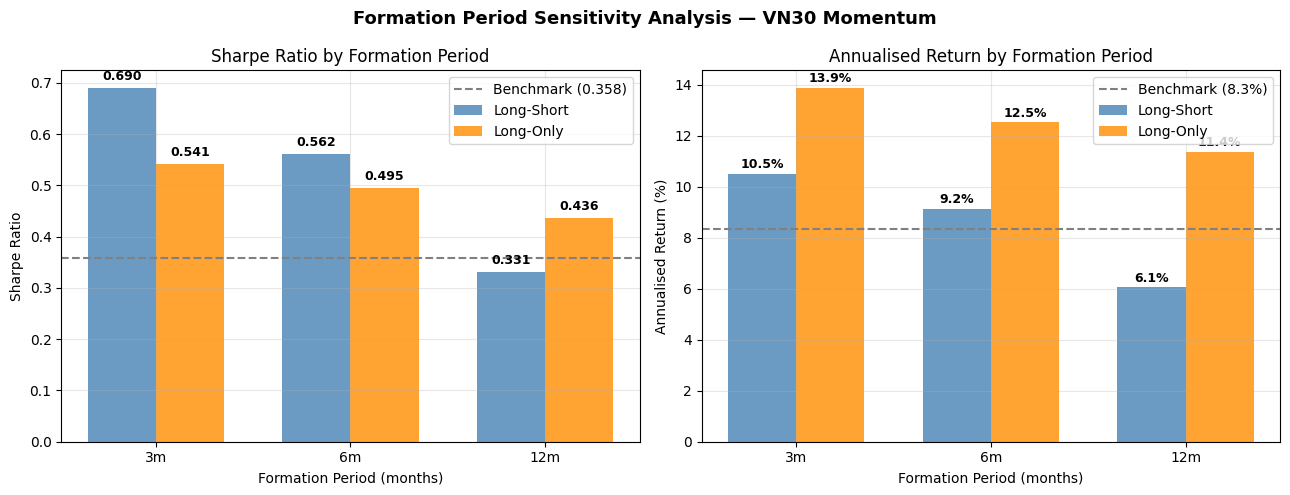

Best LS Sharpe: 0.690 (3-month formation)
Best LO Return: 13.88% (3-month formation)


In [17]:
# Formation period comparison chart
metrics = pd.read_csv("../output/all_strategies.csv", index_col=0)

formations  = [3, 6, 12]
ls_sharpes  = [metrics.loc["Sharpe Ratio", f"LS {f}-1-6"] for f in formations]
lo_sharpes  = [metrics.loc["Sharpe Ratio", f"LO {f}-1-6"] for f in formations]
ls_returns  = [metrics.loc["Ann. Return (%)", f"LS {f}-1-6"] for f in formations]
lo_returns  = [metrics.loc["Ann. Return (%)", f"LO {f}-1-6"] for f in formations]
bm_sharpe   = metrics.loc["Sharpe Ratio", "Benchmark"]
bm_return   = metrics.loc["Ann. Return (%)", "Benchmark"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Formation Period Sensitivity Analysis — VN30 Momentum",
             fontsize=13, fontweight="bold")

x     = np.arange(len(formations))
width = 0.35

# Sharpe ratio
axes[0].bar(x - width/2, ls_sharpes, width,
            label="Long-Short", color="steelblue", alpha=0.8)
axes[0].bar(x + width/2, lo_sharpes, width,
            label="Long-Only", color="darkorange", alpha=0.8)
axes[0].axhline(y=bm_sharpe, color="grey", linestyle="--",
                linewidth=1.5, label=f"Benchmark ({bm_sharpe:.3f})")
axes[0].set_xlabel("Formation Period (months)")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].set_title("Sharpe Ratio by Formation Period")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{f}m" for f in formations])
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")
for i, (ls, lo) in enumerate(zip(ls_sharpes, lo_sharpes)):
    axes[0].text(i - width/2, ls + 0.01, f"{ls:.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[0].text(i + width/2, lo + 0.01, f"{lo:.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

# Annualised return
axes[1].bar(x - width/2, ls_returns, width,
            label="Long-Short", color="steelblue", alpha=0.8)
axes[1].bar(x + width/2, lo_returns, width,
            label="Long-Only", color="darkorange", alpha=0.8)
axes[1].axhline(y=bm_return, color="grey", linestyle="--",
                linewidth=1.5, label=f"Benchmark ({bm_return:.1f}%)")
axes[1].set_xlabel("Formation Period (months)")
axes[1].set_ylabel("Annualised Return (%)")
axes[1].set_title("Annualised Return by Formation Period")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{f}m" for f in formations])
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")
for i, (ls, lo) in enumerate(zip(ls_returns, lo_returns)):
    axes[1].text(i - width/2, ls + 0.1, f"{ls:.1f}%",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[1].text(i + width/2, lo + 0.1, f"{lo:.1f}%",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../output/formation_comparison_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Best LS Sharpe: {max(ls_sharpes):.3f} (3-month formation)")
print(f"Best LO Return: {max(lo_returns):.2f}% (3-month formation)")

In [15]:
# Debug cell - run this first
metrics = pd.read_csv("../output/all_strategies.csv", index_col=0)
print("Columns:", metrics.columns.tolist())
print("Index:", metrics.index.tolist())

Columns: ['LS 3-1-6', 'LO 3-1-6', 'LS 6-1-6', 'LO 6-1-6', 'LS 12-1-6', 'LO 12-1-6', 'LS 3-1 Monthly', 'LO 3-1 Monthly', 'LS 12-1 Monthly', 'LO 12-1 Monthly', 'Benchmark']
Index: ['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Win Rate (%)', 'Best Month (%)', 'Worst Month (%)', 'N Months']
